# Analyse des performances — Prompt 4

Ce notebook analyse les résultats d'évaluation Prompt 4 (Entailment vs Contradiction) à partir des CSV générés pour les jeux **POL**, **MEDICAL** et **Combined**. Les analyses s'appuient sur le **macro F1 score** entre les deux labels.

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import json
import os
from sklearn.metrics import f1_score, confusion_matrix, classification_report

def macro_f1(y_true, y_pred):
    """Macro F1 entre les labels Entailment et Contradiction."""
    return f1_score(y_true, y_pred, labels=["Contradiction", "Entailment"], average="macro")

# Dossier des CSV et JSONL (même dossier que ce notebook)
RESULTS_DIR = "."
GRAPHS_DIR = os.path.join(RESULTS_DIR, "graphes")
os.makedirs(GRAPHS_DIR, exist_ok=True)
df_combined = pd.read_csv(os.path.join(RESULTS_DIR, "eval_fewshot_combined.csv"))
df_pol = pd.read_csv(os.path.join(RESULTS_DIR, "eval_fewshot_pol.csv"))
df_medical = pd.read_csv(os.path.join(RESULTS_DIR, "eval_fewshot_medical.csv"))
print("Combined:", df_combined.shape, "| POL:", df_pol.shape, "| MEDICAL:", df_medical.shape)
df_combined.head()

Combined: (3156, 5) | POL: (1578, 4) | MEDICAL: (1578, 4)


,index,statement_type,gold,prediction,is_correct
0,0,pol,Entailment,Contradiction,False
1,1,pol,Contradiction,Entailment,False
2,2,pol,Entailment,Entailment,True
3,3,pol,Contradiction,Contradiction,True
4,4,pol,Contradiction,Entailment,False


---
## 1. Analyse globale (fichier Combined)

Métriques générales sur l'ensemble des données combinées : **Macro F1 score** (Entailment / Contradiction), puis **matrice de confusion** (Prédictions vs Vrais labels).

In [11]:
# Métriques globales (Combined)
y_true = df_combined["gold"]
y_pred = df_combined["prediction"]
f1_global = macro_f1(y_true, y_pred)
print("=== Métriques globales (Combined) ===")
print(f"Macro F1 : {f1_global:.4f}")
print(classification_report(y_true, y_pred, target_names=["Contradiction", "Entailment"]))

=== Métriques globales (Combined) ===
Macro F1 : 0.6600
               precision    recall  f1-score   support

Contradiction       0.58      0.83      0.68      1382
   Entailment       0.80      0.53      0.64      1774

     accuracy                           0.66      3156
    macro avg       0.69      0.68      0.66      3156
 weighted avg       0.70      0.66      0.66      3156



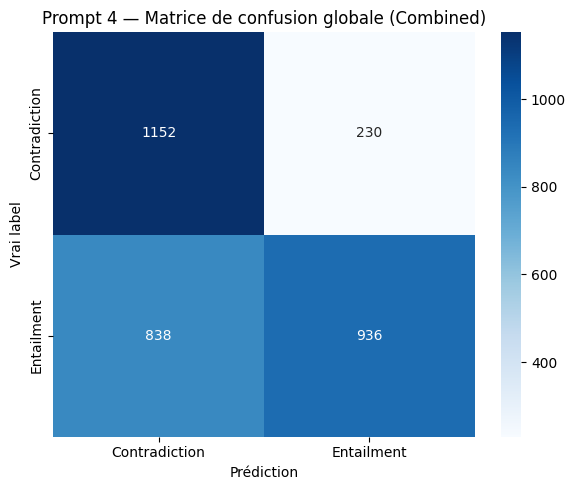

In [12]:
# Matrice de confusion globale
cm_global = confusion_matrix(y_true, y_pred, labels=["Contradiction", "Entailment"])
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm_global, annot=True, fmt="d", cmap="Blues", ax=ax,
            xticklabels=["Contradiction", "Entailment"],
            yticklabels=["Contradiction", "Entailment"])
ax.set_xlabel("Prédiction")
ax.set_ylabel("Vrai label")
ax.set_title("Prompt 4 — Matrice de confusion globale (Combined)")
plt.tight_layout()
plt.savefig(os.path.join(GRAPHS_DIR, "prompt4_confusion_combined.png"), dpi=150, bbox_inches="tight")
plt.show()

---
## 2. Analyse comparative (POL vs MEDICAL)

Séparation des résultats par type de langage : **Macro F1** par sous-groupe et deux matrices de confusion.

In [13]:
# Séparation par statement_type
df_pol_sub = df_combined[df_combined["statement_type"] == "pol"]
df_medical_sub = df_combined[df_combined["statement_type"] == "medical"]

# Macro F1 POL et MEDICAL
f1_pol = macro_f1(df_pol_sub["gold"], df_pol_sub["prediction"])
f1_medical = macro_f1(df_medical_sub["gold"], df_medical_sub["prediction"])

print("=== POL ===")
print(f"  Macro F1 : {f1_pol:.4f}")
print("\n=== MEDICAL ===")
print(f"  Macro F1 : {f1_medical:.4f}")
print("\n=== Synthèse ===")
pd.DataFrame({
    "Macro F1": [f1_pol, f1_medical]
}, index=["POL", "MEDICAL"])

=== POL ===
  Macro F1 : 0.6530

=== MEDICAL ===
  Macro F1 : 0.6666

=== Synthèse ===


,Macro F1
POL,0.653044
MEDICAL,0.666587


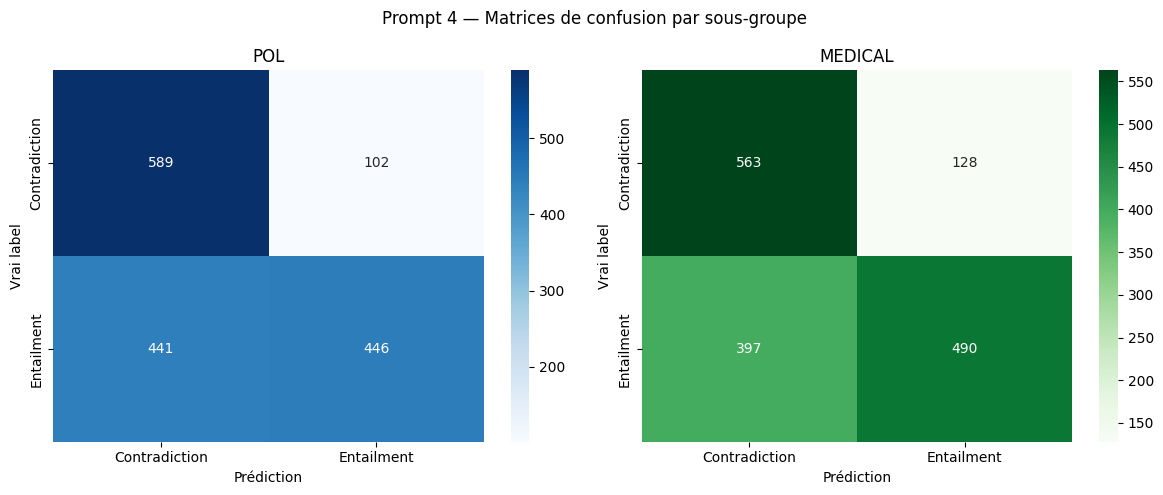

In [14]:
# Matrices de confusion POL et MEDICAL
cm_pol = confusion_matrix(df_pol_sub["gold"], df_pol_sub["prediction"], labels=["Contradiction", "Entailment"])
cm_medical = confusion_matrix(df_medical_sub["gold"], df_medical_sub["prediction"], labels=["Contradiction", "Entailment"])

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
labels_cm = ["Contradiction", "Entailment"]
sns.heatmap(cm_pol, annot=True, fmt="d", cmap="Blues", ax=axes[0],
            xticklabels=labels_cm, yticklabels=labels_cm)
axes[0].set_xlabel("Prédiction"); axes[0].set_ylabel("Vrai label"); axes[0].set_title("POL")
sns.heatmap(cm_medical, annot=True, fmt="d", cmap="Greens", ax=axes[1],
            xticklabels=labels_cm, yticklabels=labels_cm)
axes[1].set_xlabel("Prédiction"); axes[1].set_ylabel("Vrai label"); axes[1].set_title("MEDICAL")
plt.suptitle("Prompt 4 — Matrices de confusion par sous-groupe")
plt.tight_layout()
plt.savefig(os.path.join(GRAPHS_DIR, "prompt4_confusion_pol_medical.png"), dpi=150, bbox_inches="tight")
plt.show()

---
## 2. Analyse des erreurs communes (Overlap POL / MEDICAL)

Comparaison des erreurs **index par index** entre POL et MEDICAL (même patient = même index dans les deux jeux).  
- Si le modèle se trompe sur les **mêmes** patients dans les deux versions → la **logique médicale** de l'essai est probablement en cause.  
- S'il échoue sur une version mais réussit sur l'autre → le **vocabulaire** (patient vs expert) perturbe le modèle.

In [15]:
# Ensembles d'indices en erreur (même index = même patient)
errors_pol = set(df_pol[~df_pol["is_correct"]]["index"].tolist())
errors_medical = set(df_medical[~df_medical["is_correct"]]["index"].tolist())
overlap = errors_pol & errors_medical
only_pol = errors_pol - errors_medical
only_medical = errors_medical - errors_pol
n_patients = len(df_pol)
print("=== Overlap des erreurs (index = même patient) ===\n")
print(f"Nombre de patients (par jeu) : {n_patients}")
print(f"Erreurs POL     : {len(errors_pol)} ({100*len(errors_pol)/n_patients:.1f}%)")
print(f"Erreurs MEDICAL : {len(errors_medical)} ({100*len(errors_medical)/n_patients:.1f}%)")
print(f"\nErreurs sur les MÊMES patients (overlap) : {len(overlap)}")
print(f"Erreur uniquement en POL     : {len(only_pol)} (réussite en MEDICAL)")
print(f"Erreur uniquement en MEDICAL : {len(only_medical)} (réussite en POL)")
print(f"\nPart des erreurs POL qui sont aussi en erreur en MEDICAL : {100*len(overlap)/len(errors_pol):.1f}%" if errors_pol else "N/A")
print(f"Part des erreurs MEDICAL qui sont aussi en erreur en POL : {100*len(overlap)/len(errors_medical):.1f}%" if errors_medical else "N/A")

=== Overlap des erreurs (index = même patient) ===

Nombre de patients (par jeu) : 1578
Erreurs POL     : 543 (34.4%)
Erreurs MEDICAL : 525 (33.3%)

Erreurs sur les MÊMES patients (overlap) : 363
Erreur uniquement en POL     : 180 (réussite en MEDICAL)
Erreur uniquement en MEDICAL : 162 (réussite en POL)

Part des erreurs POL qui sont aussi en erreur en MEDICAL : 66.9%
Part des erreurs MEDICAL qui sont aussi en erreur en POL : 69.1%


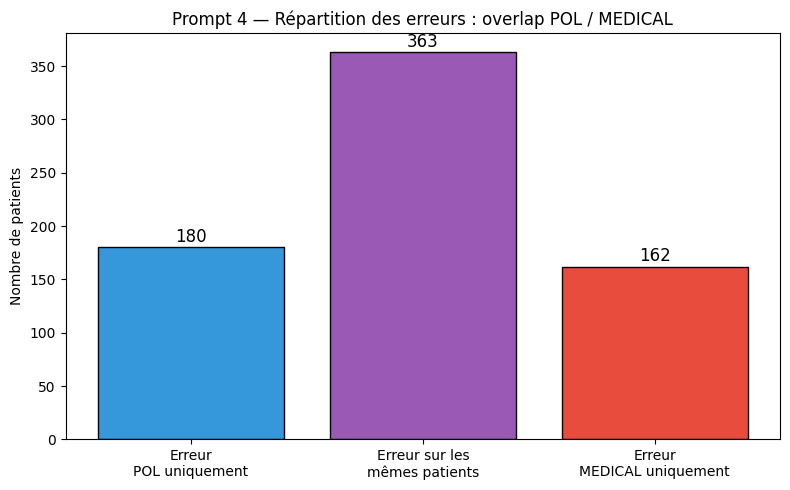

In [16]:
# Visualisation : diagramme de Venn (approché par barres)
fig, ax = plt.subplots(figsize=(8, 5))
categories = ["Erreur\nPOL uniquement", "Erreur sur les\nmêmes patients", "Erreur\nMEDICAL uniquement"]
counts = [len(only_pol), len(overlap), len(only_medical)]
colors = ["#3498db", "#9b59b6", "#e74c3c"]
bars = ax.bar(categories, counts, color=colors, edgecolor="black")
ax.set_ylabel("Nombre de patients")
ax.set_title("Prompt 4 — Répartition des erreurs : overlap POL / MEDICAL")
for b, c in zip(bars, counts):
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + 5, str(c), ha="center", fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(GRAPHS_DIR, "prompt4_erreurs_overlap_pol_medical.png"), dpi=150, bbox_inches="tight")
plt.show()

---
## 3. Analyse linguistique des erreurs few-shot (candidats vs autres)

Dans cette section, on reproduit l'analyse linguistique faite pour le finetuning :

- on définit comme **candidats** les indices en erreur **à la fois** pour POL et MEDICAL en few-shot (l'overlap déjà calculé ci-dessus),
- on calcule, sur l'ensemble du test, des **métriques linguistiques** (chevauchement lexical, densité numérique, négations, longueurs, mots-clés trial, etc.) entre la prémisse et le statement,
- on compare pour chaque métrique la moyenne sur les **candidats** vs les **autres indices**, séparément pour POL et pour MEDICAL,
- on exporte des tableaux récapitulatifs pour pouvoir les exploiter dans le papier / les figures.

In [17]:
# Chargement de `df_test` et définition des métriques linguistiques (mêmes fonctions que pour le finetuning)

from pathlib import Path

# Le notebook est dans NLI4PR/results/Fewshot_kate, donc parents[1] = NLI4PR/
NLI4PR_ROOT = Path(".").resolve().parents[1]
TEST_PARQUET = NLI4PR_ROOT / "data" / "test-00000-of-00001.parquet"

print(f"Chargement du test depuis: {TEST_PARQUET}")

df_test = pd.read_parquet(TEST_PARQUET)
print(f"Test parquet chargé: {len(df_test)} lignes")
print(f"Colonnes: {list(df_test.columns)}")

# Fonctions de calcul des métriques linguistiques (copiées depuis `analyse_finetuning.ipynb`)

def tokenize(text):
    """Mots en minuscules, alphanumeriques."""
    if pd.isna(text) or not isinstance(text, str): return set()
    return set(re.findall(r"[a-zA-Z0-9À-ÿ]+", text.lower()))

def lexical_overlap(premise, hypothesis):
    """Jaccard + % mots de l'hypothèse présents dans la prémisse (coverage)."""
    p, h = tokenize(premise), tokenize(hypothesis)
    if not p and not h: return 0.0, 0.0
    inter = len(p & h)
    union = len(p | h)
    jaccard = inter / union if union else 0.0
    coverage = inter / len(h) if h else 0.0  # % des mots de l'hypothèse dans la prémisse
    return jaccard, coverage

# Nombres en toutes lettres (anglais) pour numeric_density
NUMERIC_WORDS = frozenset({
    'one', 'two', 'three', 'four', 'five', 'six', 'seven', 'eight', 'nine', 'ten',
    'eleven', 'twelve', 'thirteen', 'fourteen', 'fifteen', 'sixteen', 'seventeen', 'eighteen', 'nineteen',
    'twenty', 'thirty', 'forty', 'fifty', 'sixty', 'seventy', 'eighty', 'ninety',
    'hundred', 'thousand', 'million', 'billion',
    'first', 'second', 'third', 'fourth', 'fifth', 'sixth', 'seventh', 'eighth', 'ninth', 'tenth',
    'half', 'double', 'single', 'triple', 'zero',
})

def numeric_density(text):
    """Chiffres, pourcentages (\d+%), unités (mg, years, etc.), et nombres en toutes lettres."""
    if pd.isna(text) or not isinstance(text, str): return 0, 0, 0, 0
    digits = len(re.findall(r"\d", text))
    pct = len(re.findall(r"\d+%", text))
    units = len(re.findall(r"\d+\s*(?:mg|g|ml|mL|kg|years?|yrs?|months?|days?|weeks?|cycles?|doses?|mg/m²|m²)", text, re.I))
    t_lower = text.lower()
    words_num = sum(1 for w in re.findall(r"\b\w+\b", t_lower) if w in NUMERIC_WORDS)
    return digits, pct, units, words_num

# Détection des négations : NLTK (tokenize + liste de mots) si dispo, sinon regex
try:
    import nltk
    nltk.download('punkt', quiet=True)
    from nltk.tokenize import word_tokenize
    _NLTK_AVAILABLE = True
except Exception:
    _NLTK_AVAILABLE = False

# Mots de négation (anglais uniquement), utilisés avec ou sans NLTK. Les formes en n't sont comptées à part.
NEGATION_WORDS = frozenset({
    'not', 'no', 'none', 'never', 'nothing', 'nowhere', 'noone', 'nobody', 'neither', 'nor', 'cannot',
})

def negation_presence(text):
    """Compte d'occurrences de mots de négation (NEGATION_WORDS + tokens en n't)."""
    if pd.isna(text) or not isinstance(text, str): return 0
    t = text.strip().lower()
    if not t: return 0
    if _NLTK_AVAILABLE:
        try:
            tokens = word_tokenize(t)
        except Exception:
            tokens = re.findall(r"\b\w+\b", t)
    else:
        tokens = re.findall(r"\b\w+\b", t)
    return sum(1 for w in tokens if w in NEGATION_WORDS or (len(w) > 2 and w.endswith("n't")))

def trial_keywords(text):
    """Présence de mots clés 'primary' / 'secondary' (trial)."""
    if pd.isna(text) or not isinstance(text, str): return 0, 0
    t = text.lower()
    primary = len(re.findall(r"primary\s+(?:trial)?", t))
    secondary = len(re.findall(r"secondary\s+(?:trial)?", t))
    return primary, secondary

def word_count(text):
    if pd.isna(text) or not isinstance(text, str): return 0
    return len(re.findall(r"[a-zA-Z0-9À-ÿ]+", text))


def compute_features_for_df(df, premise_col, statement_col):
    """
    Calcule toutes les métriques linguistiques pour un DataFrame.
    premise_col: nom de la colonne contenant la prémisse
    statement_col: nom de la colonne contenant le statement (hypothesis)
    Utilise l'index du DataFrame comme identifiant (ou la colonne 'id' si elle existe).
    """
    features_list = []
    for idx, row in df.iterrows():
        # Utiliser l'index du DataFrame comme identifiant (correspond aux indices dans les CSV)
        index_val = idx

        premise = str(row[premise_col]) if pd.notna(row[premise_col]) else ""
        statement = str(row[statement_col]) if pd.notna(row[statement_col]) else ""

        # Chevauchement lexical
        jaccard, coverage = lexical_overlap(premise, statement)

        # Densité numérique (chiffres, %, unités, nombres en toutes lettres)
        digits_p, pct_p, units_p, words_num_p = numeric_density(premise)
        digits_s, pct_s, units_s, words_num_s = numeric_density(statement)

        # Négations
        neg_p = negation_presence(premise)
        neg_s = negation_presence(statement)

        # Mots-clés trial
        prim_p, sec_p = trial_keywords(premise)
        prim_s, sec_s = trial_keywords(statement)

        # Longueur
        words_p = word_count(premise)
        words_s = word_count(statement)

        features_list.append({
            'index': index_val,
            'lexical_jaccard': jaccard,
            'lexical_coverage': coverage,
            'digits_premise': digits_p,
            'digits_statement': digits_s,
            'pct_premise': pct_p,
            'pct_statement': pct_s,
            'units_premise': units_p,
            'units_statement': units_s,
            'numeric_words_premise': words_num_p,
            'numeric_words_statement': words_num_s,
            'numeric_total': (
                digits_p + digits_s
                + units_p + units_s
                + pct_p + pct_s
                + words_num_p + words_num_s
            ),
            'neg_premise': neg_p,
            'neg_statement': neg_s,
            'neg_total': neg_p + neg_s,
            'words_premise': words_p,
            'words_statement': words_s,
            'trial_primary': prim_p + prim_s,
            'trial_secondary': sec_p + sec_s,
        })
    return pd.DataFrame(features_list)


print("Calcul des métriques pour POL (few-shot)...")
features_pol_fewshot = compute_features_for_df(df_test, 'premise', 'statement_pol')
print(f"Métriques POL (few-shot) calculées: {len(features_pol_fewshot)} lignes")

print("\nCalcul des métriques pour MEDICAL (few-shot)...")
features_medical_fewshot = compute_features_for_df(df_test, 'premise', 'statement_medical')
print(f"Métriques MEDICAL (few-shot) calculées: {len(features_medical_fewshot)} lignes")

Chargement du test depuis: C:\Users\KEBDI Lounès\Documents\Projets\NLI_Finetuning\NLI4PR\data\test-00000-of-00001.parquet
Test parquet chargé: 1578 lignes
Colonnes: ['id', 'topic_id', 'statement_medical', 'statement_pol', 'premise', 'NCT_title', 'NCT_id', 'label']
Calcul des métriques pour POL (few-shot)...
Métriques POL (few-shot) calculées: 1578 lignes

Calcul des métriques pour MEDICAL (few-shot)...
Métriques MEDICAL (few-shot) calculées: 1578 lignes


In [18]:
# Comparaison candidats (overlap erreurs POL/MEDICAL few-shot) vs autres indices

# On réutilise l'ensemble `overlap` défini plus haut comme liste d'indices candidats
candidats_indices = sorted(list(overlap))
all_indices = set(features_pol_fewshot['index'].tolist())
autres_indices = sorted(list(all_indices - set(candidats_indices)))

print(f"Candidats (overlap erreurs few-shot POL/MEDICAL): {len(candidats_indices)}")
print(f"Autres indices: {len(autres_indices)}")

# Fonction utilitaire pour faire la comparaison et résumer les résultats

def compare_groups(features_df, label, metrics_info, candidats, autres):
    print("\n=== " + label + " ===")
    print(f"Candidats: {len(candidats)} | Autres: {len(autres)}\n")
    rows = []
    for metric, metric_label in metrics_info:
        cand_vals = features_df[features_df['index'].isin(candidats)][metric]
        autres_vals = features_df[features_df['index'].isin(autres)][metric]
        mean_cand = cand_vals.mean()
        mean_autres = autres_vals.mean()
        diff = mean_cand - mean_autres
        diff_pct = (diff / mean_autres * 100) if mean_autres not in (0, None) else float('nan')
        rows.append({
            'metric': metric,
            'metric_label': metric_label,
            'mean_candidats': mean_cand,
            'mean_autres': mean_autres,
            'diff': diff,
            'diff_pct': diff_pct,
        })
        print(metric_label + ":")
        print(f"  Candidats: {mean_cand:.4f}")
        print(f"  Autres:    {mean_autres:.4f}")
        print(f"  Différence: {diff:+.4f} ({diff_pct:+.2f}%)\n")
    return pd.DataFrame(rows)


metrics_info = [
    ('lexical_jaccard', 'Chevauchement lexical (Jaccard)'),
    ('lexical_coverage', 'Coverage lexical (%)'),
    ('numeric_total', 'Densité numérique totale'),
    ('neg_total', 'Négations totales'),
    ('words_premise', 'Longueur prémisse (mots)'),
    ('words_statement', 'Longueur statement (mots)'),
    ('digits_statement', 'Chiffres dans statement'),
    ('pct_statement', 'Pourcentages dans statement'),
    ('units_statement', 'Unités dans statement'),
    ('neg_statement', 'Négations dans statement'),
    ('trial_primary', 'Mots-clés "primary trial"'),
    ('trial_secondary', 'Mots-clés "secondary trial"'),
]

# Comparaison pour POL et MEDICAL en few-shot
comparison_pol_fewshot = compare_groups(features_pol_fewshot, 'POL (few-shot)', metrics_info, candidats_indices, autres_indices)
comparison_medical_fewshot = compare_groups(features_medical_fewshot, 'MEDICAL (few-shot)', metrics_info, candidats_indices, autres_indices)

# Exporter les résultats en CSV au niveau de NLI4PR/results/
results_root = NLI4PR_ROOT / 'results'
results_root.mkdir(parents=True, exist_ok=True)

path_pol_csv = results_root / 'comparison_linguistic_pol_fewshot.csv'
path_medical_csv = results_root / 'comparison_linguistic_medical_fewshot.csv'

comparison_pol_fewshot.to_csv(path_pol_csv, index=False)
comparison_medical_fewshot.to_csv(path_medical_csv, index=False)

print("\nRésultats few-shot exportés dans:")
print(f"  - {path_pol_csv}")
print(f"  - {path_medical_csv}")

Candidats (overlap erreurs few-shot POL/MEDICAL): 363
Autres indices: 1215

=== POL (few-shot) ===
Candidats: 363 | Autres: 1215

Chevauchement lexical (Jaccard):
  Candidats: 0.0764
  Autres:    0.0757
  Différence: +0.0008 (+1.01%)

Coverage lexical (%):
  Candidats: 0.1979
  Autres:    0.1937
  Différence: +0.0042 (+2.16%)

Densité numérique totale:
  Candidats: 40.1102
  Autres:    37.5490
  Différence: +2.5612 (+6.82%)

Négations totales:
  Candidats: 4.7218
  Autres:    4.5663
  Différence: +0.1555 (+3.41%)

Longueur prémisse (mots):
  Candidats: 262.5399
  Autres:    243.3572
  Différence: +19.1827 (+7.88%)

Longueur statement (mots):
  Candidats: 121.8182
  Autres:    116.4560
  Différence: +5.3622 (+4.60%)

Chiffres dans statement:
  Candidats: 6.1570
  Autres:    6.5967
  Différence: -0.4397 (-6.67%)

Pourcentages dans statement:
  Candidats: 0.0992
  Autres:    0.1004
  Différence: -0.0012 (-1.23%)

Unités dans statement:
  Candidats: 0.6887
  Autres:    0.7391
  Différence: